### importing data

In [1]:
import pandas as pd

df = pd.read_csv("airline_revenue_dataset.csv")

print(df.head())
print(df.shape)

         Date     Origin Destination             Airline Fare_Class  \
0  2025-05-10    Chennai       Dubai              Etihad   Business   
1  2025-12-31    Chennai       Dubai              IndiGo    Economy   
2  2025-11-10    Kolkata      London            Emirates    Economy   
3  2023-05-02  Bangalore       Dubai  Singapore Airlines    Economy   
4  2024-04-11     Mumbai      London       Qatar Airways    Economy   

  Booking_Channel            Route  Capacity  Passengers  Ticket_Price  \
0           Agent    Chennai-Dubai       260         206   1629.968072   
1           Agent    Chennai-Dubai       300         217    368.765932   
2           Agent   Kolkata-London       180         160    373.309181   
3           Agent  Bangalore-Dubai       260         152    383.164282   
4           Agent    Mumbai-London       220         138    214.399326   

         Revenue  
0  335773.422756  
1   80022.207327  
2   59729.469015  
3   58240.970919  
4   29587.107027  
(120000, 11)


### data exploratation

print(df.info())

print(df.describe())

### convert date

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

### creating kpi

## load factor

In [4]:
df['Load_Factor'] = df['Passengers'] / df['Capacity']

### yield

In [5]:
df['Yield'] = df['Revenue'] / df['Passengers']

### average ticket price

In [6]:
df['Avg_Ticket_Price'] = df['Revenue'] / df['Passengers']

### route performance

### top routes

In [7]:
route_revenue = df.groupby('Route')['Revenue'].sum().sort_values(ascending=False)

print(route_revenue.head(10))

Route
Hyderabad-Dubai           2.573901e+08
Hyderabad-Kuala Lumpur    2.521826e+08
Delhi-Bangkok             2.521322e+08
Chennai-Singapore         2.512754e+08
Kolkata-Bangkok           2.512630e+08
Bangalore-Doha            2.510672e+08
Bangalore-Singapore       2.502285e+08
Chennai-Doha              2.499881e+08
Hyderabad-London          2.496679e+08
Kolkata-Doha              2.496409e+08
Name: Revenue, dtype: float64


## these are the high revenue roots

### passenger demand by route

In [8]:
route_passengers = df.groupby('Route')['Passengers'].sum().sort_values(ascending=False)

print(route_passengers.head(10))

Route
Chennai-Doha              570863
Hyderabad-Dubai           569987
Delhi-Singapore           569420
Kolkata-London            565062
Delhi-Bangkok             564960
Chennai-Singapore         563879
Hyderabad-Kuala Lumpur    562563
Kolkata-Bangkok           562017
Mumbai-Singapore          560554
Bangalore-Singapore       560282
Name: Passengers, dtype: int64


### these showing high demand markets

### pricing analysis

## average price per route

In [9]:
price_analysis = df.groupby('Route')['Ticket_Price'].mean()

print(price_analysis.sort_values(ascending=False))

Route
Kolkata-Doha              456.610155
Hyderabad-London          455.881302
Bangalore-Doha            454.520611
Hyderabad-Dubai           453.909730
Hyderabad-Singapore       452.712866
Bangalore-Dubai           451.229721
Bangalore-London          450.139882
Hyderabad-Bangkok         449.303477
Chennai-Bangkok           449.175624
Bangalore-Singapore       448.381079
Delhi-London              447.264919
Kolkata-Bangkok           446.759713
Mumbai-Dubai              446.385512
Chennai-Singapore         446.110175
Mumbai-Doha               446.013483
Delhi-Bangkok             445.845984
Chennai-Dubai             445.432414
Hyderabad-Kuala Lumpur    445.201135
Bangalore-Bangkok         445.011440
Kolkata-Kuala Lumpur      443.408170
Bangalore-Kuala Lumpur    442.393084
Hyderabad-Doha            441.736830
Kolkata-Dubai             438.540845
Chennai-London            437.821732
Chennai-Doha              437.625664
Delhi-Doha                437.138759
Kolkata-Singapore         435.92

### insights
The pricing analysis shows that routes such as Kolkata-Doha and Hyderabad-London have the highest average ticket prices, indicating strong yield potential on these routes. Medium routes like Mumbai-Dubai show slightly lower pricing but higher passenger demand, suggesting they operate as high-volume markets.

### monthly demand

In [11]:
monthly_demand = df.groupby('Month')['Passengers'].sum()

print(monthly_demand)

Month
1     1728293
2     1539566
3     1669306
4     1635976
5     1695772
6     1636718
7     1669255
8     1715849
9     1635088
10    1674778
11    1629321
12    1689730
Name: Passengers, dtype: int64


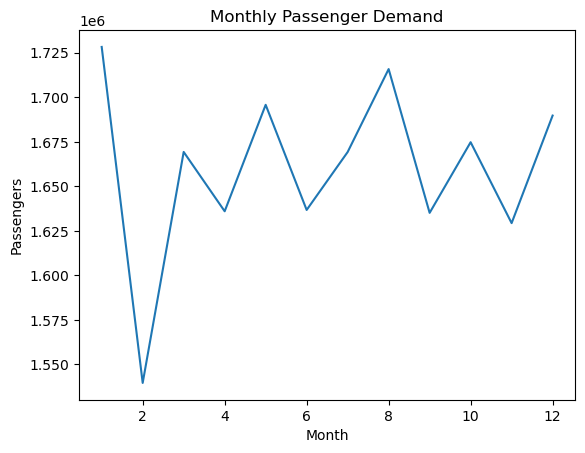

In [12]:
import matplotlib.pyplot as plt

monthly_demand.plot()

plt.title("Monthly Passenger Demand")
plt.xlabel("Month")
plt.ylabel("Passengers")

plt.show()

### insights
The above monthly chart  reveals clear seasonal fluctuations. Demand peaks during January, May, August, and December, likely due to holiday and vacation travel. February shows the lowest passenger volume, indicating a post-holiday decline in travel demand. These patterns suggest opportunities for airlines to adjust pricing strategies and capacity planning to maximize revenue during peak travel periods.

### revenue trend

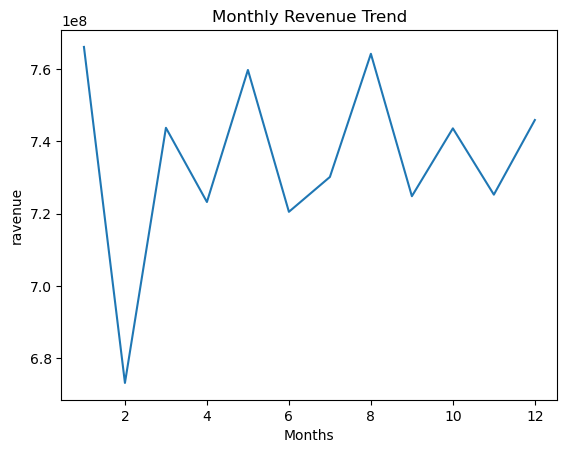

In [14]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Months")
plt.ylabel("ravenue")
plt.show()

### insights
Revenue trends indicate strong seasonal demand, with peak revenue occurring in January, May, and August, while February shows the lowest revenue levels. This pattern highlights the importance of seasonal pricing strategies and demand-driven capacity planning in airline revenue management.

### demand forcasting

In [15]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_demand, order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=6)

print("Next 6 months forecast")

print(forecast)

Next 6 months forecast
12    1.679212e+06
13    1.685214e+06
14    1.681789e+06
15    1.683743e+06
16    1.682628e+06
17    1.683265e+06
Name: predicted_mean, dtype: float64


C:\Users\jasir\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jasir\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jasir\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\jasir\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results 

### insight
The demand forecasting model predicts stable passenger demand over the next six months, averaging around 1.68 million passengers per month, indicating steady travel demand and supporting consistent revenue performance

In [16]:
df.to_csv("clean_airline_data.csv", index=False)